# Download and visualize the dataset

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms

# Transform the images, e.g., flip or rotate
# See https://pytorch.org/vision/stable/auto_examples/plot_transforms.html
# for more examples.
# these are transformations are applied at training time. Every time
# you make a pass on the data you get a new set of transformations.
train_transforms = transforms.Compose(
    [
     transforms.RandomHorizontalFlip(p=0.5), # randomly flip image horizontally
     transforms.RandomVerticalFlip(p=0.2), # randomly flip image vertically
     transforms.ColorJitter(brightness=0.1, hue=0.1, contrast=0.05), # change the colors slightly
     transforms.ToTensor(), # convert image into a tensor
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # this puts the images pixel values to [-1, 1] range
    ])

test_transforms = transforms.Compose(
    [
     transforms.ToTensor(), # convert image into a tensor
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # this puts the images pixel values to [-1, 1] range
    ])

trainset = torchvision.datasets.CIFAR10(
                                      root='./data',
                                      train=True,
                                      download=True,
                                      transform=train_transforms
                                    )
testset = torchvision.datasets.CIFAR10(root='./data',
                                       train=False,
                                       download=True,
                                       transform=test_transforms
                                       )

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')



Files already downloaded and verified
Files already downloaded and verified


In [ ]:
def create_data_loaders(batch_size):
  trainloader = torch.utils.data.DataLoader(trainset,
                                            batch_size=batch_size,
                                            shuffle=True,
                                            num_workers=2
                                            )


  testloader = torch.utils.data.DataLoader(testset,
                                          batch_size=batch_size,
                                          shuffle=False,
                                          num_workers=2
                                          )
  return trainloader, testloader

## Build the model

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.drop_out = nn.Dropout(0.75)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1) # flatten all dimensions except batch
        x = F.relu(self.fc1(x))
        x = self.drop_out(x)
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [ ]:
def compute_accuracy(net, loader):
  correct = 0
  total = 0
  device = get_device()
  net.to(device)
  # since we're not training, we don't need to calculate the gradients for our outputs
  with torch.no_grad():
      for data in loader:
          images, labels = data
          images, labels = images.to(device), labels.to(device)
          # calculate outputs by running images through the network
          outputs = net(images)
          # the class with the highest scores is what we choose as prediction
          _, predicted = torch.max(outputs.data, 1)
          total += labels.size(0)
          correct += (predicted == labels).sum().item()

  accuracy = correct / total
  return accuracy

# Train the model

In [ ]:
import time, math, copy

def get_device():
  if torch.cuda.is_available():
    print("using GPU")
    device = torch.device("cuda")
  else:
    print("using CPU")
    device = torch.device("cpu")
  return device

def train(net, optimizer, trainloader, batch_size, number_of_epochs):
  print("training network")
  device = get_device()
  net.to(device) # send the network to the device (by default its on the CPU)
  criterion = nn.CrossEntropyLoss()
  criterion = criterion.to(device)

  # Timing code, this is specifically designed to work with GPUs
  start = torch.cuda.Event(enable_timing=True)
  end = torch.cuda.Event(enable_timing=True)
  start.record()
  avg_net = copy.deepcopy(net) # this will be used to store averages of the iterates
  theta = 0.95 # this averaging parameter I will use for the geometric average
  for epoch in range(number_of_epochs):  # loop over the dataset multiple times
      running_loss = 0.0
      for i, batch in enumerate(trainloader, 0):
          # each loop here is sampling a new batch of four data points
          # get the inputs; data is a list of [inputs, labels]
          inputs, labels = batch

          # send batch to GPU
          inputs, labels = inputs.to(device), labels.to(device)

          # zero the parameter gradients
          optimizer.zero_grad()

          # forward + backward + optimize
          outputs = net(inputs)
          loss = criterion(outputs, labels)
          loss.backward()
          optimizer.step()

          # Print statistics on the observed loss function
          # this allows us to get a realtime estimate of how
          # well training is going.
          running_loss += loss.item()
          print_every_n_batches = math.ceil(10000 / batch_size)
          if i % print_every_n_batches == print_every_n_batches - 1:    # print every 10000 data points
              avg_loss = running_loss / print_every_n_batches
              print(f'[{epoch + 1}, {i + 1:5d}] loss: {avg_loss:.3f}')
              running_loss = 0.0 # reset observed loss function

          # performs a geometric average
          with torch.no_grad():
            for p, avg_p in zip(net.parameters(), avg_net.parameters()):
              # \bar{w}^{(t+1)} = \theta * \bar{w}^{(t)} + (1-\theta) * w^{(t+1)}
              # Note: add_ and mul_ are inplace operations which means that
              # avg_p is the output off the following operations.
              avg_p.mul_(theta).add_(p.data, alpha=1.0 - theta)
      iterate_test_accuracy = compute_accuracy(net, testloader)
      avg_test_accuracy = compute_accuracy(avg_net, testloader)
      print('Current iterate test accuracy = ', iterate_test_accuracy)
      print('Average iterate test accuracy = ', avg_test_accuracy)
  end.record()
  torch.cuda.synchronize() # wait until GPU is completely finished
  print('Finished training after ', start.elapsed_time(end) / 1000.0, ' seconds')
  train_accuracy = compute_accuracy(net, trainloader)
  print('Train accuracy: ', train_accuracy)
  return avg_net

In [ ]:
import torch.optim as optim

batch_size = 256
trainloader, testloader = create_data_loaders(batch_size)
net = Net()
optimizer = optim.SGD(net.parameters(), lr=0.1)
number_of_epochs = 1
avg_net = train(net, optimizer, trainloader, batch_size, number_of_epochs)

training network
using GPU
[1,    40] loss: 2.302
[1,    80] loss: 2.298
[1,   120] loss: 2.285
[1,   160] loss: 2.218
using GPU
using GPU
Current iterate test accuracy =  0.2053
Average iterate test accuracy =  0.1988
Finished training after  46.036765625  seconds
using GPU
Train accuracy:  0.19508


# Experiment with batch size timings

## Small model

In [ ]:
def time_different_batch_sizes(net, device, \
                               optimizer, \
                               min_batch_size_as_power_of_two, \
                               max_batch_size_as_power_of_two):
  batch_size_list = []
  time_per_data_point_list = []
  criterion = nn.CrossEntropyLoss()
  criterion = criterion.to(device)
  print("batch size | time per data point (milliseconds)")
  for i in range(min_batch_size_as_power_of_two, max_batch_size_as_power_of_two + 1):
    batch_size = 2 ** i
    trainloader, testloader = create_data_loaders(batch_size)
    start = torch.cuda.Event(enable_timing=True)
    end = torch.cuda.Event(enable_timing=True)
    start.record()
    n = 1
    num_batches = 5 # do this multiple times and average the results
    for i, data in enumerate(trainloader, 0):
      inputs, labels = data
      inputs, labels = inputs.to(device), labels.to(device)

      # do a step of SGD
      outputs = net(inputs)
      loss = criterion(outputs, labels)
      loss.backward()
      optimizer.step()
      n += 1
      if n == num_batches:
        break
    end.record()
    torch.cuda.synchronize() # wait until GPU is completely finished
    time_per_data_point = start.elapsed_time(end) / (batch_size * num_batches)
    print(batch_size, "  ", time_per_data_point)
    batch_size_list.append(batch_size)
    time_per_data_point_list.append(time_per_data_point)
  return batch_size_list, time_per_data_point_list

import matplotlib.pyplot as plt

def time_plot_different_batch_sizes_across_devices(net, min_batch_size_as_power_of_two, max_batch_size_as_power_of_two):
  print("GPU timing")
  device = torch.device("cuda")
  net.to(device)
  optimizer = optim.SGD(net.parameters(), lr=0.1)
  batch_size_list, gpu_time_per_data_point_list = \
    time_different_batch_sizes(net, device, optimizer, \
    min_batch_size_as_power_of_two, max_batch_size_as_power_of_two)

  print("CPU timing")
  device = torch.device("cpu")
  net.to(device)
  optimizer = optim.SGD(net.parameters(), lr=0.1)
  batch_size_list, cpu_time_per_data_point_list = \
    time_different_batch_sizes(net, device, optimizer, \
    min_batch_size_as_power_of_two, max_batch_size_as_power_of_two)

  plt.plot(batch_size_list, gpu_time_per_data_point_list, label="GPU")
  plt.plot(batch_size_list, cpu_time_per_data_point_list, label="CPU")

  plt.yscale("log")
  plt.xscale("log")
  plt.xlabel("batch size")
  plt.ylabel("miniseconds per data point processed")
  plt.legend()
  plt.show()

GPU timing
batch size | time per data point (milliseconds)
1    64.55057373046876
2    14.722665405273437
4    8.913488006591797
8    7.573208618164062
16    6.003916931152344
32    1.522646999359131
64    2.3378477096557617
128    1.9468608856201173
256    1.4351984977722168
512    0.9552227973937988
1024    0.8982111930847168
CPU timing
batch size | time per data point (milliseconds)
1    54.753857421875
2    14.405133056640626
4    7.135667419433593
8    4.245165634155273
16    2.7901464462280274
32    1.8977767944335937
64    1.394342803955078
128    1.2148658752441406
256    1.6898897171020508
512    1.221595001220703
1024    1.0371966361999512


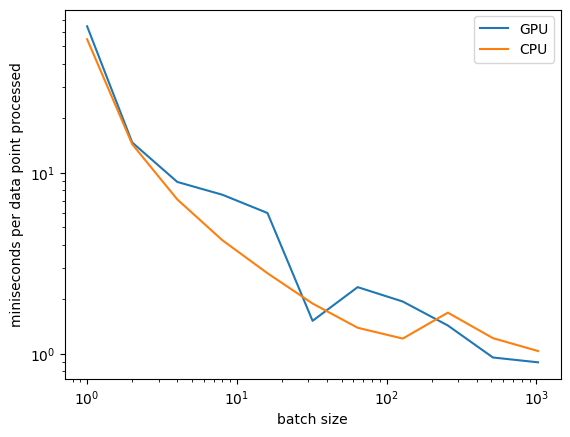

In [ ]:
min_batch_size_as_power_of_two = 0
max_batch_size_as_power_of_two = 10
time_plot_different_batch_sizes_across_devices( \
net, min_batch_size_as_power_of_two, max_batch_size_as_power_of_two)

## Much larger model

In [ ]:
from torchvision.models import resnet50
resnet = resnet50() # standard architecture with 50 layers

GPU timing
batch size | time per data point (milliseconds)
2    58.262939453125
4    15.4134521484375
8    8.627089691162109
16    5.843277359008789
32    4.755865478515625
64    3.263719177246094
128    1.76226806640625
256    1.126201057434082
512    0.9986444473266601
1024    0.9808424949645996
CPU timing
batch size | time per data point (milliseconds)
2    138.4615966796875
4    77.2977294921875
8    40.184332275390624
16    28.79895935058594
32    25.097933959960937
64    24.26659393310547
128    20.49534912109375
256    20.23160400390625
512    20.18186798095703
1024    21.41673126220703


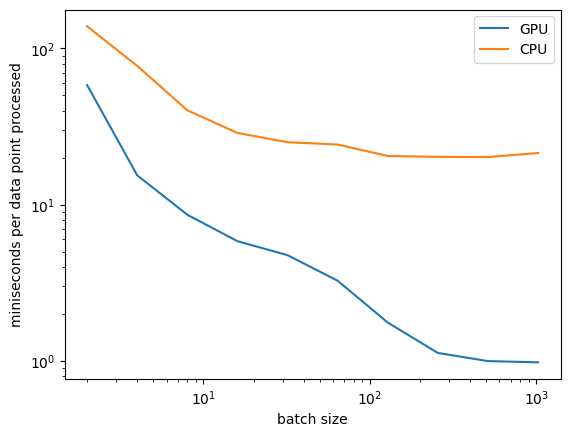

In [ ]:
min_batch_size_as_power_of_two = 1
max_batch_size_as_power_of_two = 10
time_plot_different_batch_sizes_across_devices( \
resnet, min_batch_size_as_power_of_two, max_batch_size_as_power_of_two)

In [ ]:
def tune_learning_rate(lr_list, batch_size, number_of_epochs):
  print("batch size = ", batch_size)
  best_accuracy = 0.0
  best_lr = 0.0
  for lr in lr_list:
    resnet = resnet50()
    print("learning rate = ", lr)
    optimizer = optim.SGD(resnet.parameters(), lr=lr)
    trainloader, testloader = create_data_loaders(batch_size)
    avg_resnet = train(resnet, optimizer, trainloader, batch_size, number_of_epochs)
    resnet.eval()
    test_accuracy = compute_accuracy(resnet, testloader)
    if test_accuracy > best_accuracy:
      best_accuracy = test_accuracy
      best_lr = lr
  return best_lr

In [ ]:
lr_list = [0.0001, 0.001, 0.01, 0.1]
batch_size = 64
number_of_epochs = 1
best_lr = tune_learning_rate(lr_list, batch_size, number_of_epochs)

batch size =  64
learning rate =  0.0001
training network
using GPU
[1,   157] loss: 5.706
[1,   314] loss: 3.644
[1,   471] loss: 2.921
[1,   628] loss: 2.690
using GPU
using GPU
Current iterate test accuracy =  0.1195
Average iterate test accuracy =  0.1252
Finished training after  75.1810703125  seconds
using GPU
Train accuracy:  0.11516
using GPU
learning rate =  0.001
training network
using GPU
[1,   157] loss: 3.100
[1,   314] loss: 2.472
[1,   471] loss: 2.420
[1,   628] loss: 2.389
using GPU
using GPU
Current iterate test accuracy =  0.1582
Average iterate test accuracy =  0.1556
Finished training after  75.5638671875  seconds
using GPU
Train accuracy:  0.14832
using GPU
learning rate =  0.01
training network
using GPU
[1,   157] loss: 2.920
[1,   314] loss: 2.461
[1,   471] loss: 2.317
[1,   628] loss: 2.152
using GPU
using GPU
Current iterate test accuracy =  0.1615
Average iterate test accuracy =  0.3677
Finished training after  76.8572421875  seconds
using GPU
Train accurac

In [ ]:
print(best_lr)

0.1


## Run the best learning rate for more epochs

In [ ]:
resnet = resnet50()
batch_size = 64
optimizer = optim.SGD(resnet.parameters(), lr=best_lr)
number_of_epochs = 30
trainloader, testloader = create_data_loaders(batch_size)
avg_net = train(resnet, optimizer, trainloader, batch_size, number_of_epochs)

training network
using GPU
[1,   157] loss: 6.504
[1,   314] loss: 3.863
[1,   471] loss: 3.022
[1,   628] loss: 2.684
using GPU
using GPU
Current iterate test accuracy =  0.1763
Average iterate test accuracy =  0.3676
[2,   157] loss: 2.242
[2,   314] loss: 2.105
[2,   471] loss: 2.063
[2,   628] loss: 1.932
using GPU
using GPU
Current iterate test accuracy =  0.2037
Average iterate test accuracy =  0.4251
[3,   157] loss: 1.832
[3,   314] loss: 1.792
[3,   471] loss: 1.777
[3,   628] loss: 1.698
using GPU
using GPU
Current iterate test accuracy =  0.2919
Average iterate test accuracy =  0.4676
[4,   157] loss: 1.639
[4,   314] loss: 1.614
[4,   471] loss: 1.588
[4,   628] loss: 1.580
using GPU
using GPU
Current iterate test accuracy =  0.3787
Average iterate test accuracy =  0.5058
[5,   157] loss: 1.517
[5,   314] loss: 1.496
[5,   471] loss: 1.497
[5,   628] loss: 1.480
using GPU
using GPU
Current iterate test accuracy =  0.3654
Average iterate test accuracy =  0.5348
[6,   157] lo

In [ ]:
resnet.eval()
compute_accuracy(resnet, testloader)

using GPU


0.7073